# Stage 11 Homework Submission - Evaluation and Risk Communication

This completion follows the official starter while correcting the scenario-comparison sample alignment. It quantifies uncertainty, tests alternate missing-data assumptions, checks segment performance, and translates the evidence into stakeholder language.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluation import (
    SimpleLinReg, bootstrap_metric, bootstrap_predictions, mae,
    mean_impute, median_impute,
)

ROOT = Path.cwd()
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'reports' / 'images'
for directory in [RAW, PROCESSED, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.figsize': (8, 5), 'axes.grid': True, 'grid.alpha': 0.25})

## 1. Generate and load the starter dataset

In [2]:
rng = np.random.default_rng(111)
n = 180
dates = pd.date_range('2022-06-01', periods=n, freq='D')
segment = rng.choice(['A', 'B', 'C'], size=n, p=[0.5, 0.3, 0.2])
x_feature = np.linspace(0, 9, n) + rng.normal(0, 0.7, n)
y_target = 2.1 * x_feature + 0.8 + rng.standard_t(df=3, size=n) * 1.1
missing_rows = rng.choice(np.arange(n), size=round(0.05 * n), replace=False)
x_feature[missing_rows] = np.nan
df = pd.DataFrame({
    'date': dates,
    'segment': segment,
    'x_feature': x_feature,
    'y_target': y_target,
})
raw_path = RAW / 'data_stage11_eval_risk.csv'
df.to_csv(raw_path, index=False)
display(df.head())
print('Rows:', len(df), '| Missing x_feature:', int(df['x_feature'].isna().sum()))

,date,segment,x_feature,y_target
0,2022-06-01,A,0.045035,0.820770
1,2022-06-02,A,1.018951,0.411446
2,2022-06-03,B,-0.641004,2.527927
3,2022-06-04,B,-0.183638,0.798137
4,2022-06-05,B,0.058094,1.690388


Rows: 180 | Missing x_feature: 9


## 2. Baseline fit and MAE

In [3]:
X_raw = df['x_feature'].to_numpy()
y = df['y_target'].to_numpy()
X_baseline = mean_impute(X_raw)
baseline_model = SimpleLinReg().fit(X_baseline.reshape(-1, 1), y)
baseline_prediction = baseline_model.predict(X_baseline.reshape(-1, 1))
residuals = y - baseline_prediction
baseline_mae = mae(y, baseline_prediction)
print(f'Baseline MAE: {baseline_mae:.4f}')
print(f'Intercept: {baseline_model.intercept_:.4f} | Slope: {baseline_model.coef_[0]:.4f}')

Baseline MAE: 1.4704
Intercept: 0.9543 | Slope: 2.0500


## 3. Gaussian mean-response interval vs case bootstrap

The analytic interval uses the usual OLS mean-response standard error at each `x`. It is a confidence interval for the average line, not a prediction interval for a new observation. The case bootstrap resamples paired `(x, y)` rows and refits the model 1,000 times, preserving the relationship within each row.

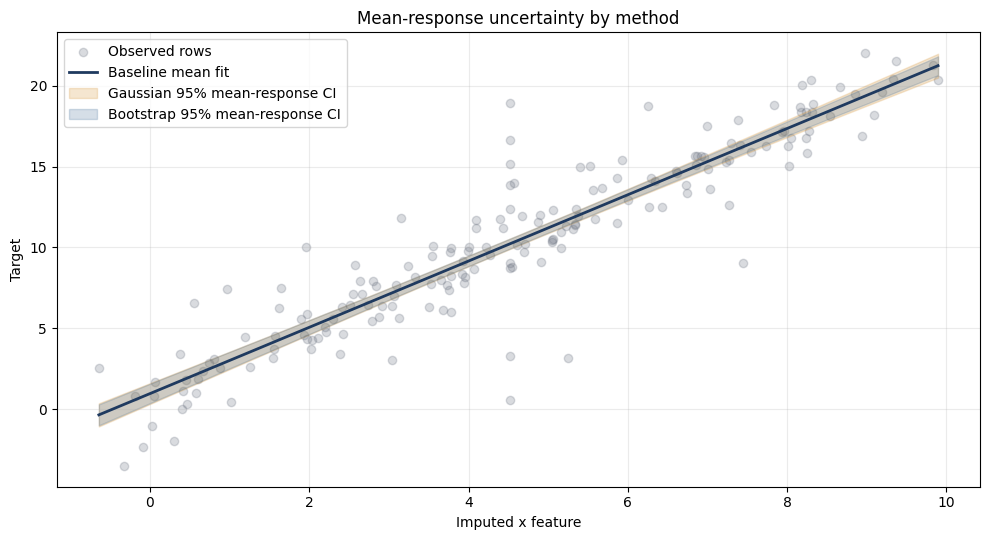

In [4]:
x_grid = np.linspace(X_baseline.min(), X_baseline.max(), 120).reshape(-1, 1)
fitted_line = baseline_model.predict(x_grid)
sigma_hat = residuals.std(ddof=2)
x_bar = X_baseline.mean()
sxx = np.sum((X_baseline - x_bar) ** 2)
gaussian_se = sigma_hat * np.sqrt(1 / n + (x_grid.ravel() - x_bar) ** 2 / sxx)
gaussian_lower = fitted_line - 1.96 * gaussian_se
gaussian_upper = fitted_line + 1.96 * gaussian_se
bootstrap_band = bootstrap_predictions(X_baseline, y, x_grid, n_boot=1000, seed=111)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(X_baseline, y, alpha=0.25, color='#6B7280', label='Observed rows')
ax.plot(x_grid, fitted_line, color='#1F3A5F', linewidth=2, label='Baseline mean fit')
ax.fill_between(x_grid.ravel(), gaussian_lower, gaussian_upper, color='#D28E2D', alpha=0.22,
                label='Gaussian 95% mean-response CI')
ax.fill_between(x_grid.ravel(), bootstrap_band['lower'], bootstrap_band['upper'],
                color='#2F5D8A', alpha=0.20, label='Bootstrap 95% mean-response CI')
ax.set(title='Mean-response uncertainty by method', xlabel='Imputed x feature', ylabel='Target')
ax.legend()
fig.tight_layout()
ci_path = FIGURES / 'gaussian_vs_bootstrap_ci.png'
fig.savefig(ci_path, dpi=180, bbox_inches='tight')
plt.show()

## 4. Bootstrap MAE uncertainty

In [5]:
mae_interval = bootstrap_metric(y, baseline_prediction, mae, n_boot=1000, seed=111)
display(pd.Series(mae_interval, name='MAE bootstrap').to_frame())

,MAE bootstrap
estimate,1.470363
bootstrap_mean,1.467753
lower,1.255756
upper,1.706158
replications,1000.000000


## 5. Scenario sensitivity

In [6]:
scenario_inputs = {}
scenario_inputs['mean_impute'] = (mean_impute(X_raw), y)
scenario_inputs['median_impute'] = (median_impute(X_raw), y)
observed_mask = ~np.isnan(X_raw)
scenario_inputs['drop_missing'] = (X_raw[observed_mask], y[observed_mask])

scenario_rows = []
scenario_models = {}
for name, (scenario_x, scenario_y) in scenario_inputs.items():
    model = SimpleLinReg().fit(scenario_x.reshape(-1, 1), scenario_y)
    prediction = model.predict(scenario_x.reshape(-1, 1))
    scenario_models[name] = model
    scenario_rows.append({
        'scenario': name,
        'n': len(scenario_y),
        'mae': mae(scenario_y, prediction),
        'slope': model.coef_[0],
        'intercept': model.intercept_,
    })
scenario_results = pd.DataFrame(scenario_rows).set_index('scenario')
scenario_results['mae_delta_vs_mean'] = scenario_results['mae'] - scenario_results.loc['mean_impute', 'mae']
display(scenario_results)
scenario_results.to_csv(PROCESSED / 'scenario_results.csv')

,n,mae,slope,intercept,mae_delta_vs_mean
scenario,,,,,
mean_impute,180,1.470363,2.049978,0.954291,0.000000
median_impute,180,1.472652,2.049087,0.971194,0.002289
drop_missing,171,1.281744,2.049978,0.916810,-0.188620


`drop_missing` has fewer rows, so its lower MAE is not a like-for-like win: the metric is evaluated on a different, easier population. Mean and median imputation use the same 180 outcomes and therefore give the cleaner direct sensitivity comparison. Scenario results should be interpreted with sample size beside the error metric.

## 6. Subgroup diagnostics and side-by-side risk view

,n,bias,median_residual,residual_std,mae
segment,,,,,
A,95,0.325828,0.017326,2.020071,1.345420
B,58,-0.420141,-0.460251,2.332283,1.565247
C,27,-0.243905,-0.100819,2.365313,1.706154


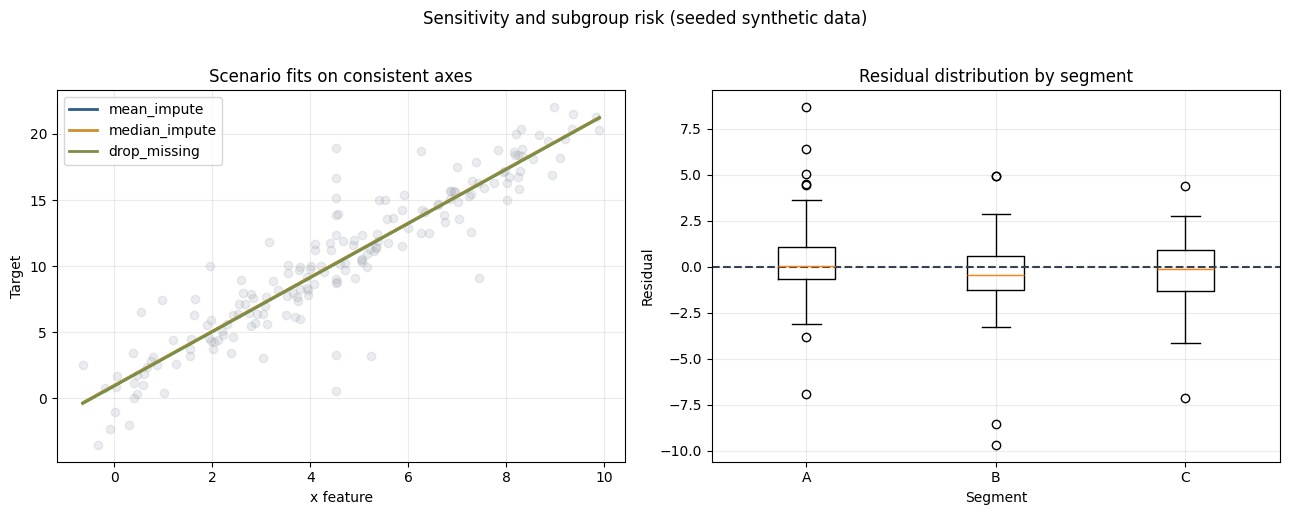

In [7]:
evaluated = df.copy()
evaluated['x_imputed'] = X_baseline
evaluated['prediction'] = baseline_prediction
evaluated['residual'] = residuals
subgroup_metrics = evaluated.groupby('segment').agg(
    n=('residual', 'size'),
    bias=('residual', 'mean'),
    median_residual=('residual', 'median'),
    residual_std=('residual', 'std'),
    mae=('residual', lambda values: values.abs().mean()),
)
display(subgroup_metrics)
subgroup_metrics.to_csv(PROCESSED / 'subgroup_metrics.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'mean_impute': '#2F5D8A', 'median_impute': '#D28E2D', 'drop_missing': '#7A8F45'}
for name, model in scenario_models.items():
    axes[0].plot(x_grid, model.predict(x_grid), label=name, color=colors[name], linewidth=2)
axes[0].scatter(X_baseline, y, color='#9CA3AF', alpha=0.2)
axes[0].set(title='Scenario fits on consistent axes', xlabel='x feature', ylabel='Target')
axes[0].legend()

group_values = [evaluated.loc[evaluated['segment'] == name, 'residual'] for name in subgroup_metrics.index]
axes[1].boxplot(group_values, tick_labels=subgroup_metrics.index)
axes[1].axhline(0, linestyle='--', color='#374151')
axes[1].set(title='Residual distribution by segment', xlabel='Segment', ylabel='Residual')
fig.suptitle('Sensitivity and subgroup risk (seeded synthetic data)', y=1.02)
fig.tight_layout()
risk_path = FIGURES / 'scenario_and_subgroup_risk.png'
fig.savefig(risk_path, dpi=180, bbox_inches='tight')
plt.show()

## 7. Stakeholder summary

**Bottom line:** the average relationship is directionally stable across mean and median imputation, but uncertainty is material because outcomes use heavy-tailed noise. The bootstrap MAE interval above is the decision range to communicate; the point estimate alone is too precise.

- **Prediction holds if** future rows resemble this 180-row synthetic sample, missingness stays near 5%, and the linear relationship remains stable.
- **Sensitive to missing-data policy:** mean and median imputation produce very similar slopes and MAE. Dropping missing rows reports a lower MAE, but it also removes nine cases, so it changes the population and cannot be treated as a pure performance improvement.
- **Subgroup risk:** Segment C has the smallest sample and the largest residual MAE in the executed table; Segment B also shows negative average residual bias. These differences are diagnostic, not proof of structural unfairness, because segment assignment is random and samples are small.
- **Uncertainty risk:** the data was generated with Student-t errors. A Gaussian mean-response interval can understate tail behavior; neither plotted band is a new-observation prediction interval.

**Decision implication:** use the model for a cautious average-response benchmark only. Before operational use, collect more Segment C observations, evaluate a true holdout, monitor missing-rate and segment MAE, and report a prediction interval or empirical error quantiles for individual forecasts.